In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Path to dataset files: /kaggle/input/breast-cancer-wisconsin-data


In [3]:
 from google.colab import files
 files.upload() # upload the Kaggle ZIP
 !mkdir -p /content/breast_cancer_data
 !unzip -q your_zip_name.zip -d /content/breast_cancer_data
 !ls -lah /content/breast_cancer_data | head


Saving data.csv to data.csv
unzip:  cannot find or open your_zip_name.zip, your_zip_name.zip.zip or your_zip_name.zip.ZIP.
total 8.0K
drwxr-xr-x 2 root root 4.0K Mar  3 13:17 .
drwxr-xr-x 1 root root 4.0K Mar  3 13:17 ..


In [6]:
import pandas as pd
import os
import glob
DATA_DIR = path # Use the path where kagglehub downloaded the dataset
csv_files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
print('CSV files found:', csv_files)
if len(csv_files) == 0:
    raise FileNotFoundError('No CSV found in the dataset folder. Check unzip output.')
csv_path = csv_files[0]
print('Loading:', csv_path)
df = pd.read_csv(csv_path)
print('Shape:', df.shape)
df.head()

CSV files found: ['/kaggle/input/breast-cancer-wisconsin-data/data.csv']
Loading: /kaggle/input/breast-cancer-wisconsin-data/data.csv
Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [7]:
print('Columns:', list(df.columns))
# Missing values summary
missing = df.isna().sum()
print('\nMissing values (non-zero):')
print(missing[missing > 0])
# Target distribution
print('\nDiagnosis counts:')
print(df['diagnosis'].value_counts())
print('\nDiagnosis proportions:')
print(df['diagnosis'].value_counts(normalize=True).round(3))


Columns: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Missing values (non-zero):
Unnamed: 32    569
dtype: int64

Diagnosis counts:
diagnosis
B    357
M    212
Name: count, dtype: int64

Diagnosis proportions:
diagnosis
B    0.627
M    0.373
Name: proportion, dtype: float64


In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Drop known non-feature columns if present
for col in ['id', 'Unnamed: 32']:
    if col in df.columns:
        df = df.drop(columns=[col])
# Encode label
if 'diagnosis' not in df.columns:
    raise ValueError('Expected a diagnosis column. Please check your CSV file.')
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})
X = df.drop(columns=['diagnosis'])
y = df['diagnosis'].astype(int)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)
print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

Train: (398, 30) Val: (85, 30) Test: (86, 30)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
logreg = LogisticRegression(max_iter=2000, random_state=42)
logreg.fit(X_train_sc, y_train)
pred_lr = logreg.predict(X_test_sc)
print('=== Logistic Regression ===')
print('Accuracy:', round(accuracy_score(y_test, pred_lr), 4))
print('F1 :', round(f1_score(y_test, pred_lr), 4))
print('\nConfusion matrix:\n', confusion_matrix(y_test, pred_lr))
print('\nClassification report:\n', classification_report(y_test, pred_lr,
digits=4))

=== Logistic Regression ===
Accuracy: 0.9767
F1 : 0.9688

Confusion matrix:
 [[53  1]
 [ 1 31]]

Classification report:
               precision    recall  f1-score   support

           0     0.9815    0.9815    0.9815        54
           1     0.9688    0.9688    0.9688        32

    accuracy                         0.9767        86
   macro avg     0.9751    0.9751    0.9751        86
weighted avg     0.9767    0.9767    0.9767        86



In [12]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print('=== Random Forest ===')
print('Accuracy:', round(accuracy_score(y_test, pred_rf), 4))
print('F1 :', round(f1_score(y_test, pred_rf), 4))
print('\nConfusion matrix:\n', confusion_matrix(y_test, pred_rf))
print('\nClassification report:\n', classification_report(y_test, pred_rf,
digits=4))

=== Random Forest ===
Accuracy: 0.9884
F1 : 0.9841

Confusion matrix:
 [[54  0]
 [ 1 31]]

Classification report:
               precision    recall  f1-score   support

           0     0.9818    1.0000    0.9908        54
           1     1.0000    0.9688    0.9841        32

    accuracy                         0.9884        86
   macro avg     0.9909    0.9844    0.9875        86
weighted avg     0.9886    0.9884    0.9883        86



In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
tf.random.set_seed(42)
mlp = models.Sequential([
layers.Input(shape=(X_train_sc.shape[1],)),
layers.Dense(64, activation='relu'),
layers.Dropout(0.2),
layers.Dense(32, activation='relu'),
layers.Dropout(0.2),
layers.Dense(1, activation='sigmoid')
])
mlp.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
loss='binary_crossentropy',
metrics=['accuracy']
)
early = callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
restore_best_weights=True)
history = mlp.fit(
X_train_sc, y_train,
validation_data=(X_val_sc, y_val),
epochs=60,
batch_size=16,
verbose=1,
  callbacks=[early]
)


Epoch 1/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6578 - loss: 0.5995 - val_accuracy: 0.9294 - val_loss: 0.3017
Epoch 2/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9393 - loss: 0.2849 - val_accuracy: 0.9529 - val_loss: 0.1606
Epoch 3/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9526 - loss: 0.1809 - val_accuracy: 0.9529 - val_loss: 0.1211
Epoch 4/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9743 - loss: 0.1407 - val_accuracy: 0.9647 - val_loss: 0.1039
Epoch 5/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9667 - loss: 0.1233 - val_accuracy: 0.9765 - val_loss: 0.0950
Epoch 6/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9714 - loss: 0.1090 - val_accuracy: 0.9765 - val_loss: 0.0900
Epoch 7/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9808 - loss: 0.0942 - val_accuracy: 0.9765 - val_loss: 0.0855
Epoch 8/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9684 - loss: 0.1136 - val_accuracy: 0.9765 - val_loss

In [15]:
import numpy as np
dl_proba = mlp.predict(X_test_sc, verbose=0).ravel()
dl_pred = (dl_proba >= 0.5).astype(int)
print('=== Deep Learning (MLP) ===')
print('Accuracy:', round(accuracy_score(y_test, dl_pred), 4))
print('F1 :', round(f1_score(y_test, dl_pred), 4))
print('\nConfusion matrix:\n', confusion_matrix(y_test, dl_pred))
print('\nClassification report:\n', classification_report(y_test, dl_pred,
digits=4))
# Step 8 — Compare models (summary table)
import pandas as pd
summary = pd.DataFrame(
    [
        {'Model': 'Logistic Regression (ML)', 'Accuracy': accuracy_score(y_test, pred_lr), 'F1': f1_score(y_test, pred_lr)},
        {'Model': 'Random Forest (ML)', 'Accuracy': accuracy_score(y_test, pred_rf), 'F1': f1_score(y_test, pred_rf)},
        {'Model': 'Deep Learning (MLP)', 'Accuracy': accuracy_score(y_test, dl_pred), 'F1': f1_score(y_test, dl_pred)},
    ]
).sort_values('Accuracy', ascending=False)
summary

=== Deep Learning (MLP) ===
Accuracy: 0.9884
F1 : 0.9841

Confusion matrix:
 [[54  0]
 [ 1 31]]

Classification report:
               precision    recall  f1-score   support

           0     0.9818    1.0000    0.9908        54
           1     1.0000    0.9688    0.9841        32

    accuracy                         0.9884        86
   macro avg     0.9909    0.9844    0.9875        86
weighted avg     0.9886    0.9884    0.9883        86



,Model,Accuracy,F1
1,Random Forest (ML),0.988372,0.984127
2,Deep Learning (MLP),0.988372,0.984127
0,Logistic Regression (ML),0.976744,0.968750


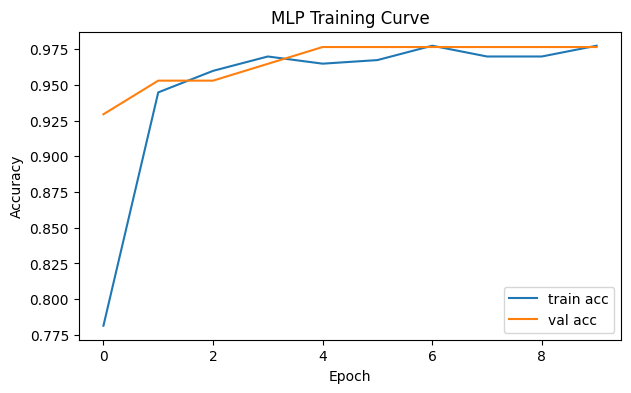

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MLP Training Curve')
plt.legend()
plt.show()


**The END of Part-1**

**TASK 2**

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print("✅ Dataset loaded:", file_name)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(list(df.columns))
# Check label column
label_col = "Fraud_Label" if "Fraud_Label" in df.columns else df.columns[-1]
print("\nLabel column:", label_col)
df.head()

Saving realistic_fraud_dataset.csv to realistic_fraud_dataset (1).csv
✅ Dataset loaded: realistic_fraud_dataset (1).csv
Rows: 5000
Columns: 13

Column names:
['Transaction_Amount', 'Transaction_Frequency_24h', 'Avg_Transaction_Amount_7d', 'Time_Since_Last_Transaction', 'Device_Risk_Score', 'Location_Risk_Score', 'Merchant_Risk_Level', 'Account_Age_Days', 'Failed_Login_Attempts', 'Card_Present_Flag', 'International_Transaction_Flag', 'Behaviour_Anomaly_Score', 'Fraud_Label']

Label column: Fraud_Label


,Transaction_Amount,Transaction_Frequency_24h,Avg_Transaction_Amount_7d,Time_Since_Last_Transaction,Device_Risk_Score,Location_Risk_Score,Merchant_Risk_Level,Account_Age_Days,Failed_Login_Attempts,Card_Present_Flag,International_Transaction_Flag,Behaviour_Anomaly_Score,Fraud_Label
0,103.198632,11.708023,-0.428199,2.331456,2.363514,-3.348085,0.194557,384.417960,6.025434,0,1,0.045506,0
1,91.412984,17.671464,-2.114292,3.292929,-0.946327,3.105203,-0.339868,259.537505,11.730849,1,0,-1.856414,0
2,24.843019,1.152564,-1.547622,4.535614,2.394840,-1.982799,-0.322607,126.008772,4.039310,1,1,-1.042931,0
3,187.191866,11.795201,-1.160000,1.972907,0.877295,-4.051658,-0.060130,739.489051,7.909406,0,1,-0.545966,0
4,60.883398,23.720904,-4.447524,0.747979,-1.608840,4.315827,8.347229,1305.592846,10.577227,0,0,0.871799,0


Non-Fraud: 3984
Fraud: 1016


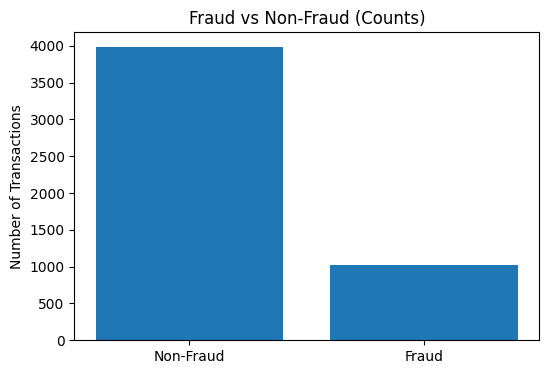

In [18]:
counts = df[label_col].value_counts()
fraud = counts.get(1, 0)
non_fraud = counts.get(0, 0)
print("Non-Fraud:", non_fraud)
print("Fraud:", fraud)
plt.figure(figsize=(6,4))
plt.bar(["Non-Fraud", "Fraud"], [non_fraud, fraud])
plt.title("Fraud vs Non-Fraud (Counts)")
plt.ylabel("Number of Transactions")
plt.show()

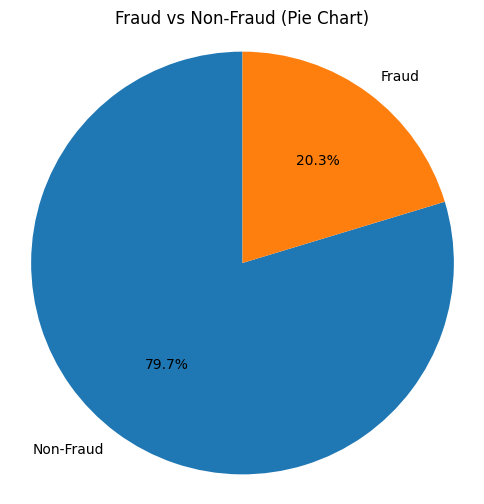

In [19]:
plt.figure(figsize=(6,6))
plt.pie([non_fraud, fraud],
 labels=["Non-Fraud", "Fraud"],
 autopct="%1.1f%%",
 startangle=90)
plt.title("Fraud vs Non-Fraud (Pie Chart)")
plt.axis("equal")
plt.show()

In [21]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from tensorflow import keras
# Features/label
X = df.drop(columns=[label_col])
y = df[label_col].astype(int)
# Split
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.25, random_state=42, stratify=y
)
# ---- Random Forest ----
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print("🌲 Random Forest Accuracy:", round(rf_accuracy, 4))
# ---- Deep Learning (scale features) ----
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
dl = keras.Sequential([
 keras.layers.Dense(128, activation='relu', input_shape=(X_train_s.shape[1],)),
 keras.layers.BatchNormalization(),
 keras.layers.Dropout(0.3),
 keras.layers.Dense(64, activation='relu'),
 keras.layers.Dropout(0.3),
 keras.layers.Dense(1, activation='sigmoid')
])
dl.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dl.fit(X_train_s, y_train, epochs=30, batch_size=128, verbose=0)
dl_loss, dl_accuracy = dl.evaluate(X_test_s, y_test, verbose=0)
print("🧠 Deep Learning Accuracy:", round(dl_accuracy, 4))

🌲 Random Forest Accuracy: 0.968


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


🧠 Deep Learning Accuracy: 0.9816


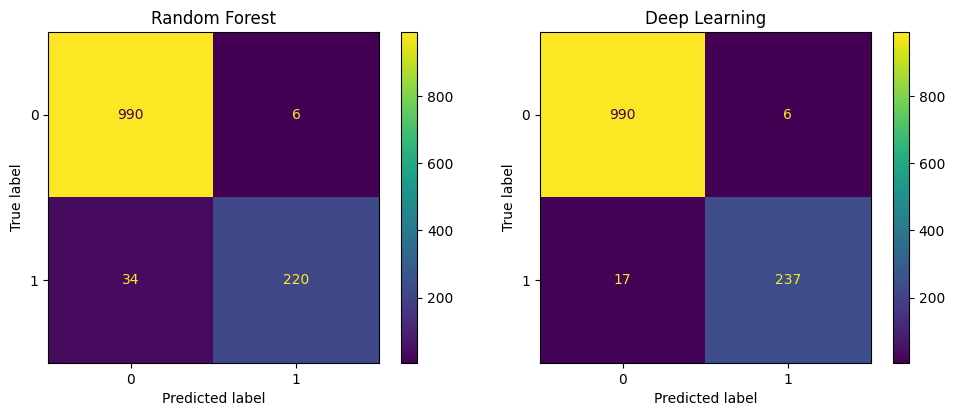

RF Confusion Matrix:
 [[990   6]
 [ 34 220]]
DL Confusion Matrix:
 [[990   6]
 [ 17 237]]


In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# DL predictions (threshold 0.5)
dl_pred = (dl.predict(X_test_s, verbose=0).ravel() >= 0.5).astype(int)
cm_rf = confusion_matrix(y_test, rf_pred)
cm_dl = confusion_matrix(y_test, dl_pred)
fig, ax = plt.subplots(1, 2, figsize=(10,4))
ConfusionMatrixDisplay(cm_rf).plot(ax=ax[0])
ax[0].set_title("Random Forest")
ConfusionMatrixDisplay(cm_dl).plot(ax=ax[1])
ax[1].set_title("Deep Learning")
plt.tight_layout()
plt.show()
print("RF Confusion Matrix:\n", cm_rf)
print("DL Confusion Matrix:\n", cm_dl)


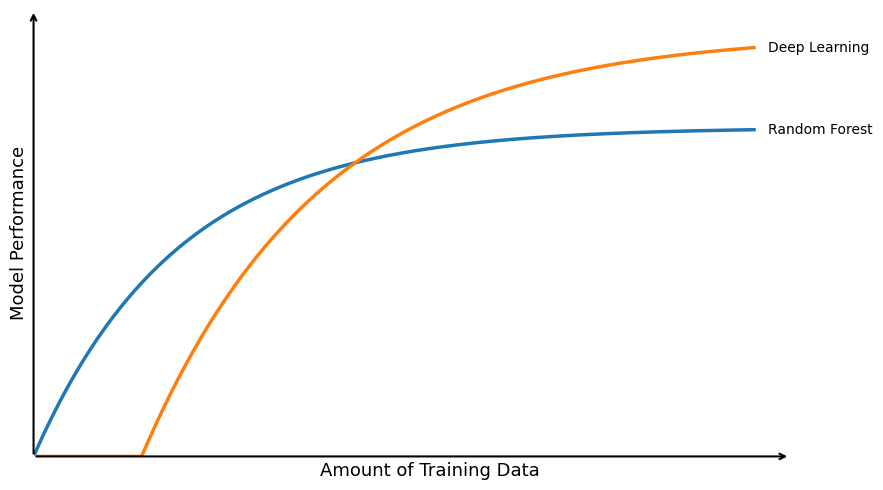

In [23]:
import numpy as np
import matplotlib.pyplot as plt
# X-axis represents amount of training data
x = np.linspace(0, 1, 400)
# Simulated performance curves
# Random Forest: strong early, saturates earlier
rf_performance = 0.70 * (1 - np.exp(-5 * x))
# Deep Learning: slower start, higher ceiling with more data
dl_performance = 0.90 * (1 - np.exp(-4 * np.clip(x - 0.15, 0, 1)))
plt.figure(figsize=(9, 5))
plt.plot(x, rf_performance, linewidth=2.5)
plt.plot(x, dl_performance, linewidth=2.5)
plt.xlabel("Amount of Training Data", fontsize=13)
plt.ylabel("Model Performance", fontsize=13)
plt.xticks([])
plt.yticks([])
plt.box(False)
# Add labels near end of curves
plt.text(1.02, rf_performance[-1], "Random Forest", va="center")
plt.text(1.02, dl_performance[-1], "Deep Learning", va="center")
# Add arrow-style axes
ax = plt.gca()
ax.annotate("", xy=(1.05, 0), xytext=(0, 0),
arrowprops=dict(arrowstyle="->", lw=1.5))
ax.annotate("", xy=(0, 0.95), xytext=(0, 0),
arrowprops=dict(arrowstyle="->", lw=1.5))
ax.set_xlim(0, 1.1)
ax.set_ylim(0, 0.95)
plt.tight_layout()
plt.show()